In [ ]:
from pathlib import Path
import sys


sys.path.append(str(Path().resolve().parent))


                           

                                                            
                                            

BASE_DIR = Path().resolve()
PROJECT_ROOT = BASE_DIR.parent   #to go un up the the root
DATA_DIR = PROJECT_ROOT / "data"

# Root directory of dataset
root = Path(DATA_DIR)


import numpy as np
import matplotlib.pyplot as plt 
from scipy.signal import find_peaks
import pandas as pd

In [ ]:


def build_df(root):

    label_map = {
        1: "correct",
        2: "fast",
        3: "low_amplitude"
    }

    dfs = []   # store all partial dataframes

    for subject_dir in root.glob("s*"):
        for exercise_dir in subject_dir.glob("e*"):
            for unit_dir in exercise_dir.glob("u*"):

                file_path = unit_dir / "test.txt"

                df = pd.read_csv(file_path, sep=";")

                df["subject"] = subject_dir.name
                df["exercise"] = exercise_dir.name
                df["unit"] = unit_dir.name

                

                label_map = {
                    0: "correct",
                    1: "fast",
                    2: "low_amplitude"
                }

                segment_length = len(df) // 30

                df["execution_type"] = None

                for i in range(30):
                    start = i * segment_length
                    end = (i + 1) * segment_length

                    label_group = i // 10
                    label = label_map[label_group]

                    df.loc[start:end, "execution_type"] = label

                dfs.append(df)   # collect dataframe

    final_df = pd.concat(dfs, ignore_index=True)

    return final_df

In [48]:
df=build_df(root)


In [49]:
df[(df['subject']=='s1') & (df['exercise']=='e1') ]

,time index,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,mag_x,mag_y,mag_z,subject,exercise,unit,execution_type
0,1,-9.685645,-1.645149,0.505022,-0.020696,0.009202,-0.008566,0.589728,0.453403,-0.075234,s1,e1,u1,correct
1,2,-9.648184,-1.645353,0.513125,-0.008165,-0.001407,-0.003256,0.587024,0.453644,-0.075593,s1,e1,u1,correct
2,3,-9.700570,-1.615223,0.512321,-0.004447,0.011059,-0.008589,0.589691,0.454598,-0.075525,s1,e1,u1,correct
3,4,-9.685627,-1.630183,0.497591,-0.026110,0.009183,-0.008554,0.589240,0.452864,-0.074705,s1,e1,u1,correct
4,5,-9.655697,-1.630194,0.460742,-0.008109,0.001231,-0.005950,0.589647,0.452882,-0.076429,s1,e1,u1,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29740,5945,-4.223868,-7.541800,-4.607269,-0.016858,-0.001904,-0.011902,0.003246,0.725318,0.231512,s1,e1,u5,None
29741,5946,-4.253123,-7.531929,-4.612775,-0.006980,-0.021866,-0.013705,0.005410,0.724710,0.231259,s1,e1,u5,None
29742,5947,-4.233624,-7.536894,-4.607502,-0.013551,-0.001552,0.000465,0.004094,0.725666,0.233084,s1,e1,u5,None
29743,5948,-4.228771,-7.517463,-4.622438,-0.020245,-0.013049,-0.019876,0.004089,0.724876,0.232979,s1,e1,u5,None


In [50]:
merged_df = df.pivot(
    index=["subject", "exercise", "time index"],
    columns="unit",
    values=["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z", "mag_x", "mag_y", "mag_z"]
)

merged_df.columns = [f"{sensor}_{unit}" for sensor, unit in merged_df.columns]
merged_df = merged_df.reset_index()




In [51]:
subject2ex1=merged_df[(merged_df['subject']=='s2') & (merged_df['exercise']=='e1') ]

In [52]:
import matplotlib.pyplot as plt
import numpy as np

#### accelerometer magnitude of exercise 2 for subject 2 of one sensor unit

exercise 2 is moving the leg, the most used sensor shuold be only s2

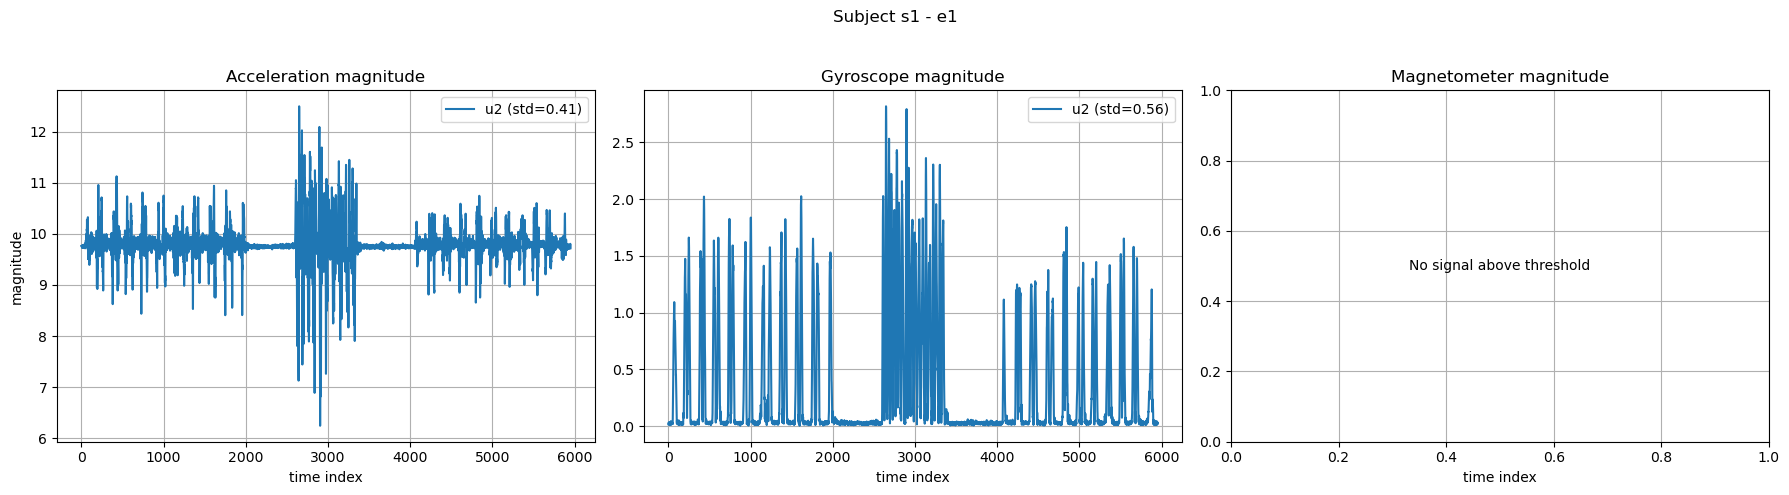

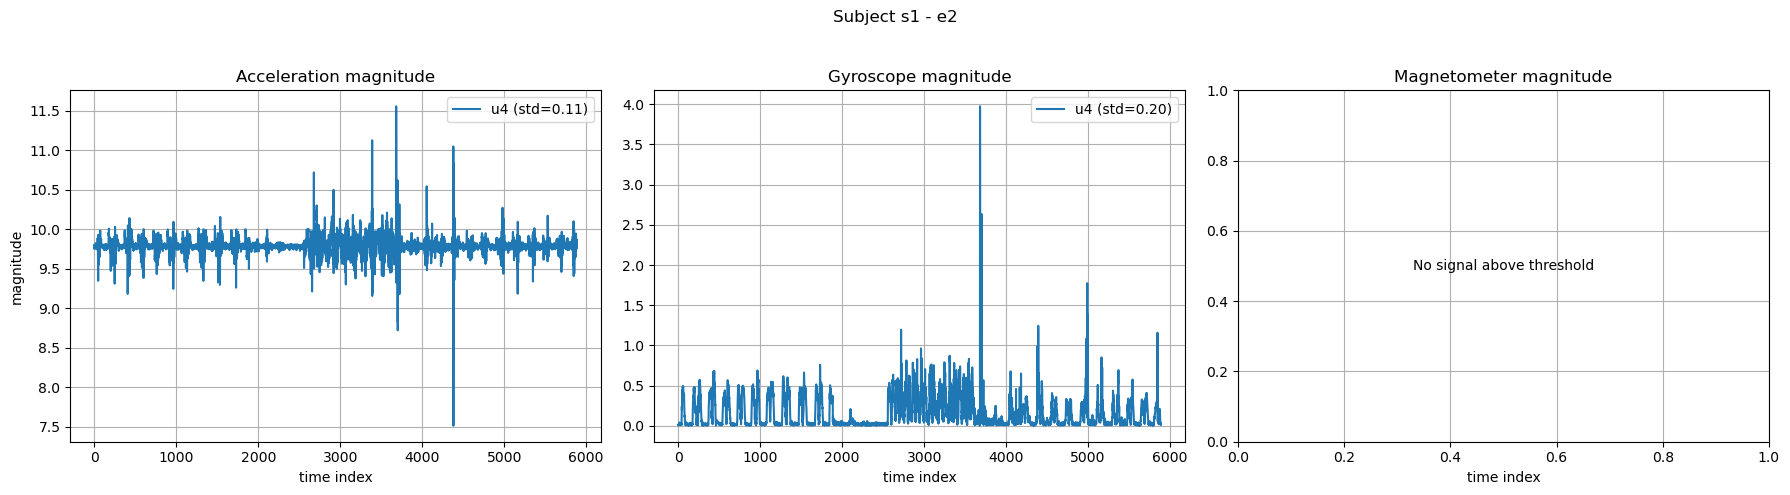

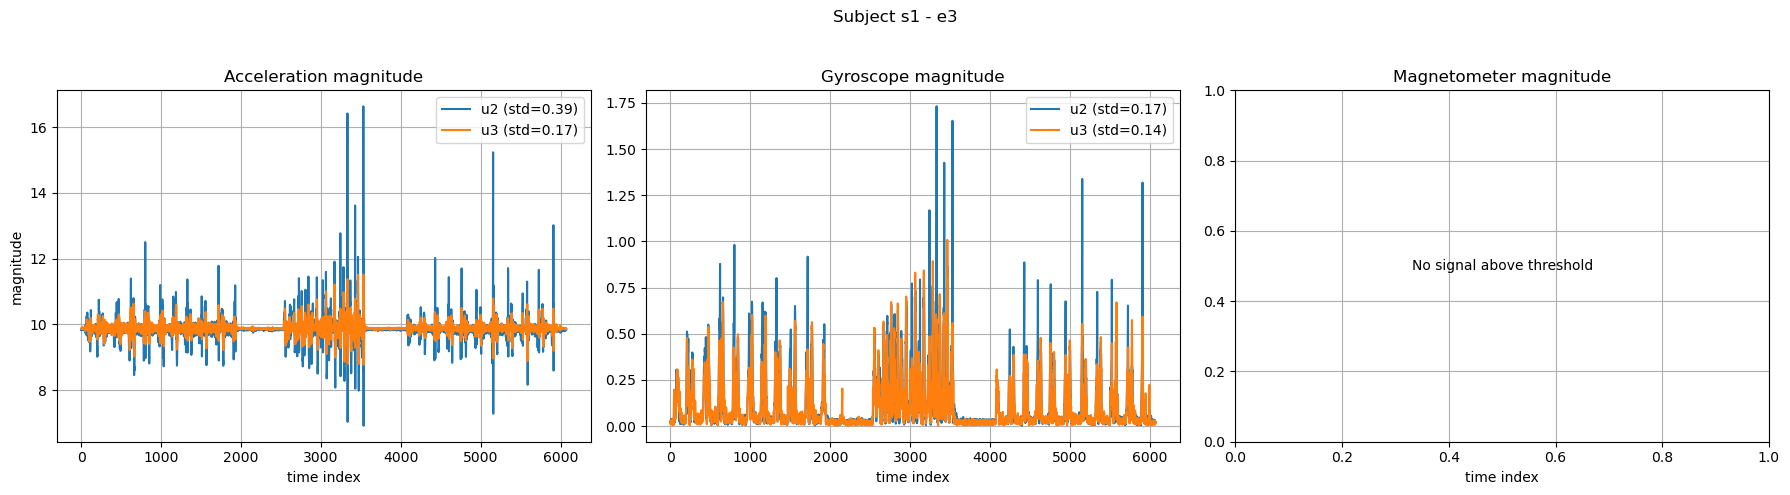

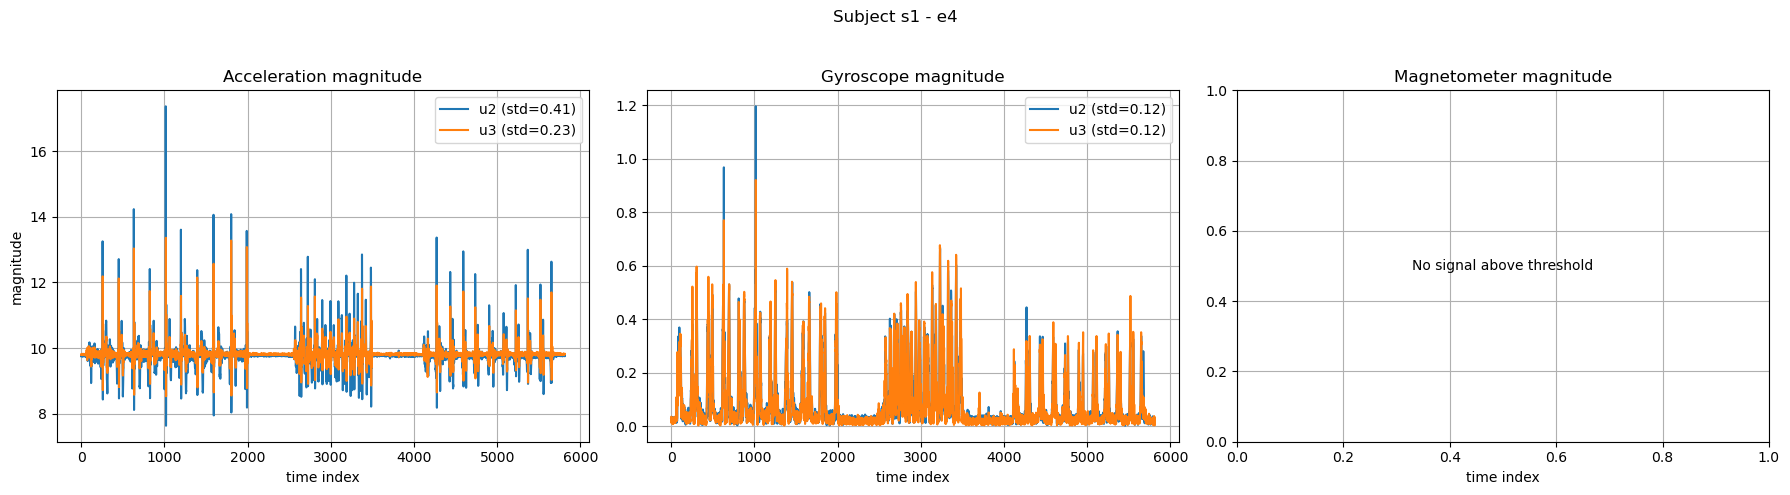

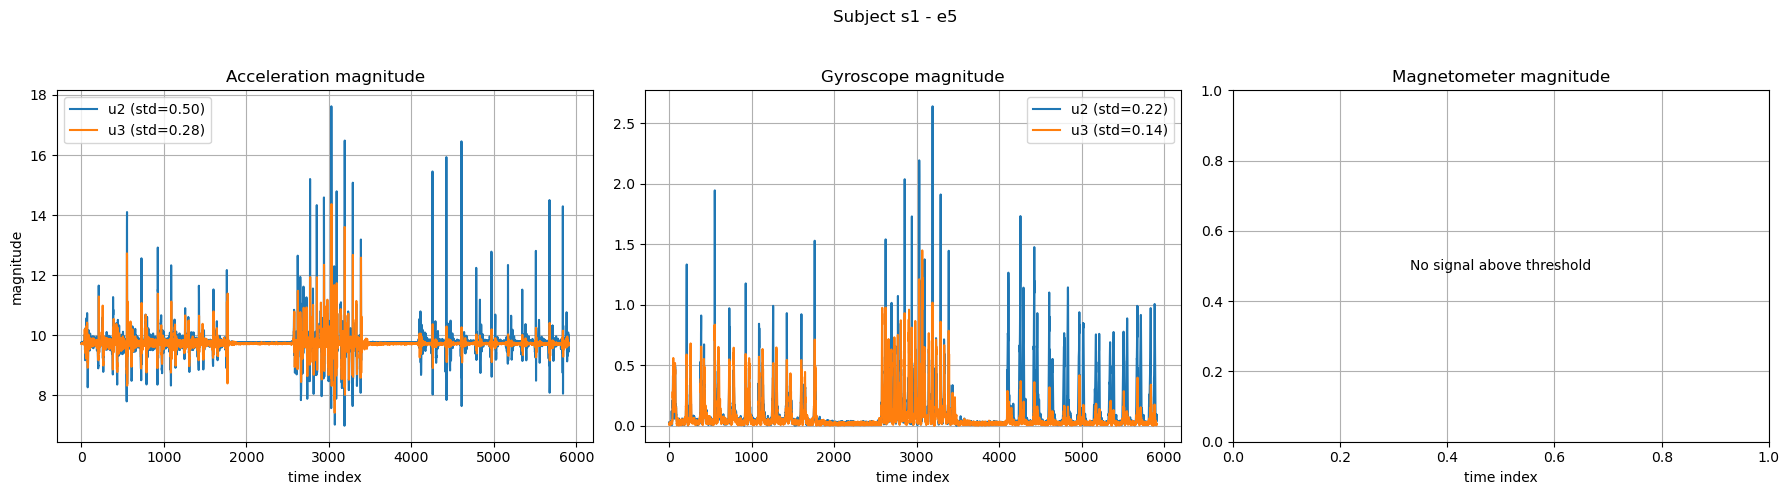

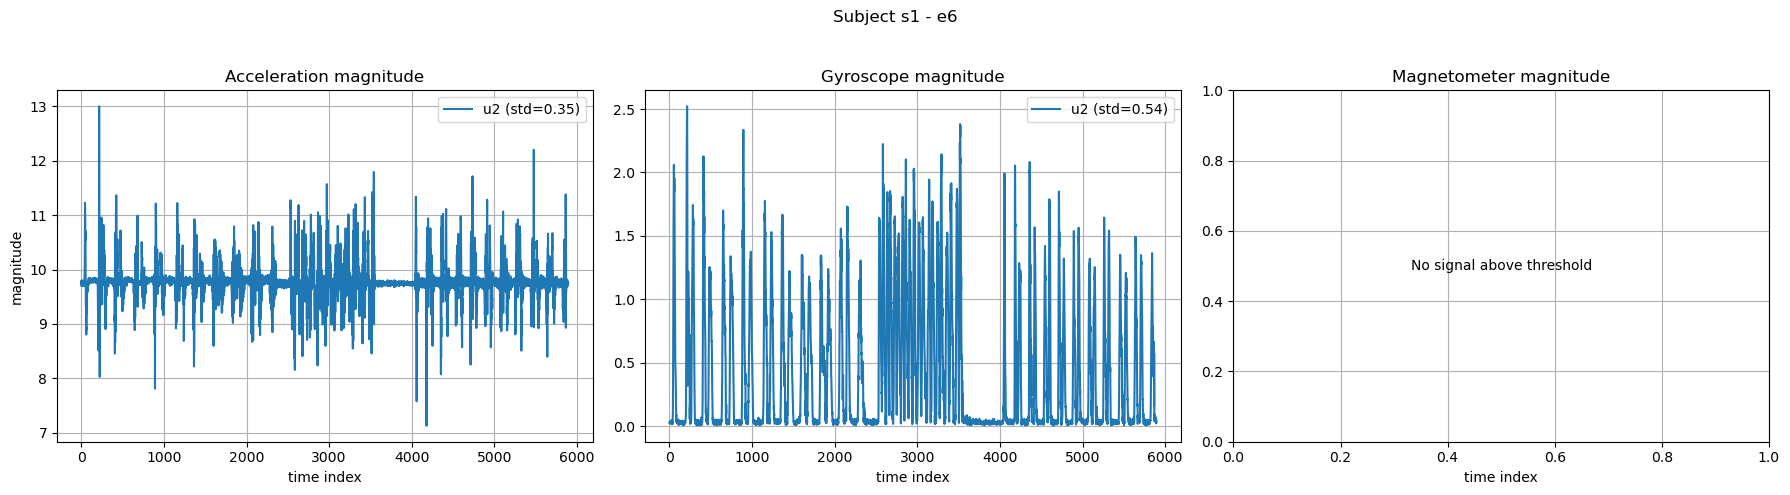

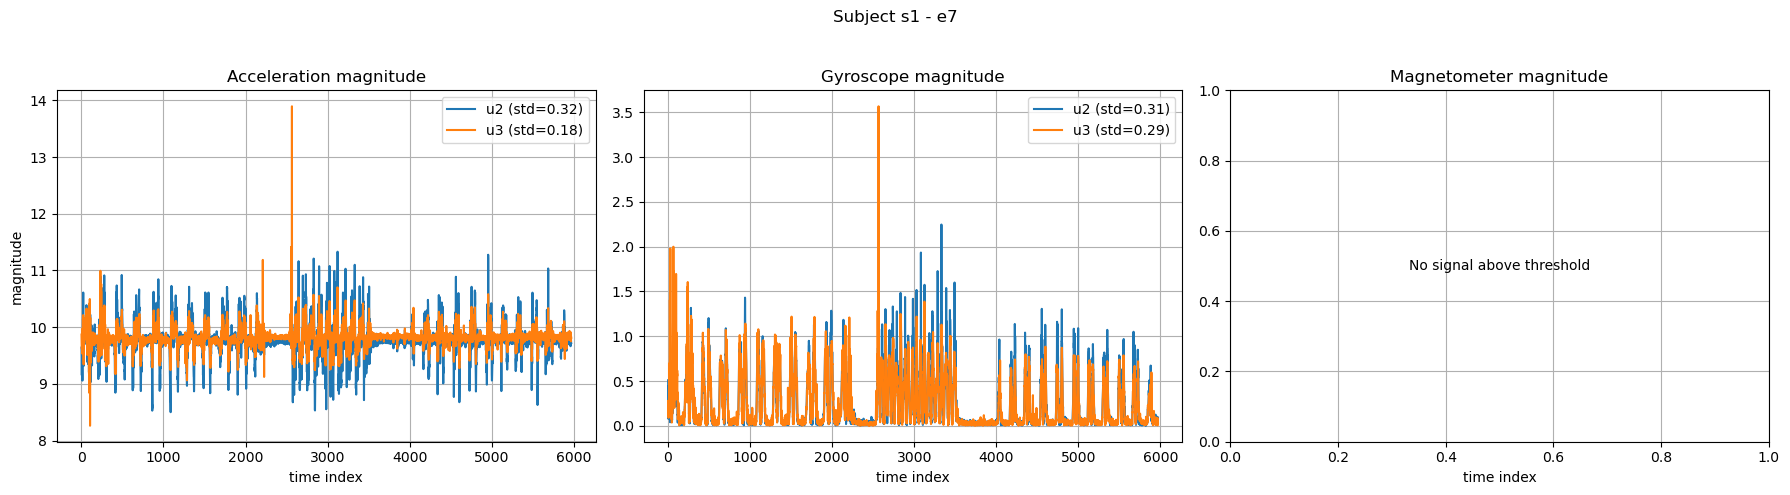

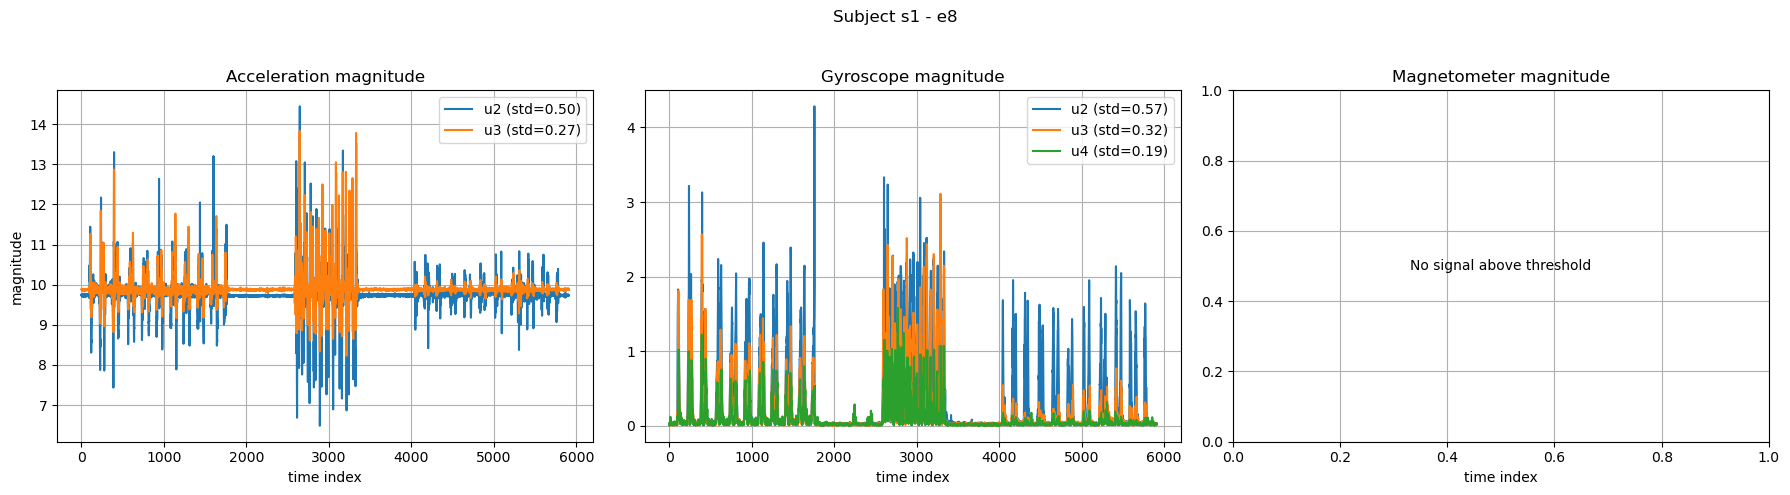

In [66]:
subject = merged_df[merged_df['subject'] == 's1']
exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

for exercise in exercises:
    subject_ex = subject[subject['exercise'] == exercise].copy()

    if subject_ex.empty:
        print(f"No data for {exercise}")
        continue

    # Compute magnitudes for all units
    for u in range(1, 6):
        subject_ex[f"acc_mag_u{u}"] = np.sqrt(
            subject_ex[f"acc_x_u{u}"]**2 +
            subject_ex[f"acc_y_u{u}"]**2 +
            subject_ex[f"acc_z_u{u}"]**2
        )

        subject_ex[f"gyr_mag_u{u}"] = np.sqrt(
            subject_ex[f"gyr_x_u{u}"]**2 +
            subject_ex[f"gyr_y_u{u}"]**2 +
            subject_ex[f"gyr_z_u{u}"]**2
        )

        subject_ex[f"mag_mag_u{u}"] = np.sqrt(
            subject_ex[f"mag_x_u{u}"]**2 +
            subject_ex[f"mag_y_u{u}"]**2 +
            subject_ex[f"mag_z_u{u}"]**2
        )

    threshold = 0.1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Subject s1 - {exercise}")

    sensor_info = [
        ("acc", "Acceleration magnitude", axes[0]),
        ("gyr", "Gyroscope magnitude", axes[1]),
        ("mag", "Magnetometer magnitude", axes[2]),
    ]

    anything_plotted = False

    for sensor_prefix, title, ax in sensor_info:
        plotted_here = False

        for u in range(1, 6):
            std = subject_ex[f"{sensor_prefix}_mag_u{u}"].std()

            if std > threshold:
                ax.plot(
                    subject_ex["time index"],
                    subject_ex[f"{sensor_prefix}_mag_u{u}"],
                    label=f"u{u} (std={std:.2f})"
                )
                plotted_here = True
                anything_plotted = True

        ax.set_title(title)
        ax.set_xlabel("time index")
        ax.grid(True)

        if sensor_prefix == "acc":
            ax.set_ylabel("magnitude")

        if plotted_here:
            ax.legend()
        else:
            ax.text(
                0.5, 0.5, "No signal above threshold",
                transform=ax.transAxes,
                ha="center", va="center"
            )

    if anything_plotted:
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
    else:
        plt.close()
        print(f"No sensor exceeded threshold for {exercise}")

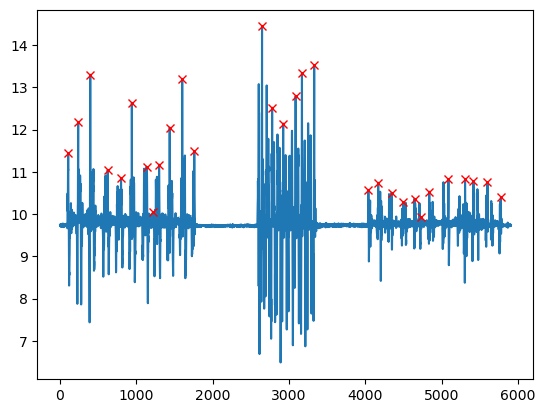

In [ ]:
signal = subject_ex["acc_mag_u2"].to_numpy()
peaks, _ = find_peaks(signal, distance=80, prominence=0.6)

plt.plot(signal)
plt.plot(peaks, signal[peaks], "xr")
plt.show()



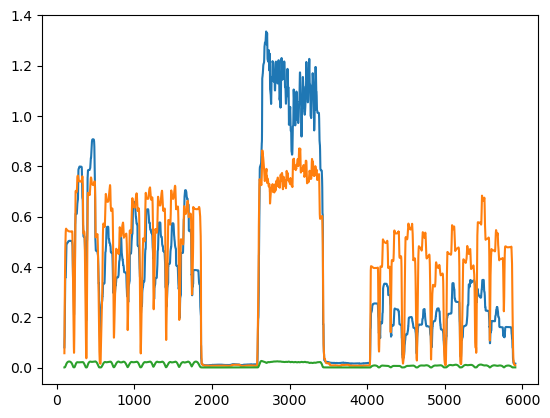

In [68]:
columns=["acc_mag_u2", 'gyr_mag_u2', 'mag_mag_u2']

for column in columns:
    signal = subject_ex[column].to_numpy()
    energy = pd.Series(signal).rolling(100).std()

    plt.plot(energy)

In [ ]:

subject=merged_df[merged_df['subject']=='s1']

exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

for exercise in exercises:
    subject_ex = subject[subject['exercise'] == exercise].copy()
    
    subject_ex["acc_mag_u1"] = np.sqrt(      
        subject_ex["acc_x_u1"]**2 +
        subject_ex["acc_y_u1"]**2 +
        subject_ex["acc_z_u1"]**2
    )

    subject_ex["acc_mag_u2"] = np.sqrt(      
        subject_ex["acc_x_u2"]**2 +
        subject_ex["acc_y_u2"]**2 +
        subject_ex["acc_z_u2"]**2
    )

    subject_ex["acc_mag_u3"] = np.sqrt(      
        subject_ex["acc_x_u3"]**2 +
        subject_ex["acc_y_u3"]**2 +
        subject_ex["acc_z_u3"]**2
    )

    subject_ex["acc_mag_u4"] = np.sqrt(      
        subject_ex["acc_x_u4"]**2 +
        subject_ex["acc_y_u4"]**2 +
        subject_ex["acc_z_u4"]**2
    )

    subject_ex["acc_mag_u5"] = np.sqrt(      
        subject_ex["acc_x_u5"]**2 +
        subject_ex["acc_y_u5"]**2 +
        subject_ex["acc_z_u5"]**2
    )

    threshold = 0.2   # example threshold

    for u in range(1,6):

        std = subject_ex[f"acc_mag_u{u}"].std()

        if std > threshold:
            plt.plot(subject_ex["time index"], subject_ex[f"acc_mag_u{u}"],
                    label=f"u{u} (std={std:.2f})")



    fig, axes= plt.subplots(ncols=3, nrows=2, figsize=(10,10))
    fig.suptitle(exercise)
    axes[0,0].plot(subject_ex["time index"], subject_ex["acc_mag_u1"])
    axes[0,0].set_title('u1 accelerometer')

    axes[0,1].plot(subject_ex["time index"], subject_ex["acc_mag_u2"])
    axes[0,1].set_title('u2 accelerometer')

    axes[1,0].plot(subject_ex["time index"], subject_ex["acc_mag_u3"])
    axes[1,0].set_title('u3 accelerometer')


    axes[1,1].plot(subject_ex["time index"],subject_ex["acc_mag_u4"])
    axes[1,1].set_title('u4 accelerometer')


    axes[1,2].plot(subject_ex["time index"], subject_ex["acc_mag_u5"])
    axes[1,2].set_title('u5 accelerometer')

    plt.show()